# Reproduced Figure 4

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

#=================================================================
# ! IMPORTANT: UPDATE THIS PATH FOR YOUR OWN MACHINE!  
# 
# ➤ Please replace it with the full path to your "WD-IMBH-Relativistic-Tides" folder.
#   Example:
#        sys.path.append("/Users/your_username/your_project_folder/WD-IMBH-Relativistic-Tides")
#
#  Tip: Keep this notebook in the same directory as the "WD-IMBH-Relativistic-Tides" folder for easier path management.
import os 
os.chdir("/your_username/your_project_folder/WD-IMBH-Relativistic-Tides") 
# os.chdir("/Users/yang/My_Project_Files_Yang_Yang/WD-IMBH-Relativistic-Tides")
print(os.getcwd())
#=================================================================


/Users/yang/My_Project_Files_Yang_Yang/WD-IMBH-Relativistic-Tides


In [14]:
"""
📌 Plot Reproduction Script: Fully Reconstruct the Original Scientific Figure from Saved Data

This script loads data from the following three `.npz` files to precisely reproduce the original plot:
1. `FIG_4_colormap_field_data.npz`   → Grid-based field data (used for `contourf`)
2. `FIG_4_extracted_streamlines.npz` → All streamline trajectories (numerically integrated + GW-only)
3. `FIG_4_annotation_points.npz`     → Coordinates of the yellow annotated points in the figure

All data were generated by the "data extraction module" appended to the original plotting script.
This reproduction script requires **no original physics functions** (e.g., `integrate_streamline1`)—only NumPy and Matplotlib.

Author: Yang Yang  
Date: March 2026
"""

# ====================================================================
#  Part 1: Load and Explain the Data Content
# ==================================================================== 
print("Loading colormap field data (FIG_4_colormap_field_data.npz)...")
field = np.load('data_npz/FIG_4_colormap_field_data.npz')

# 【Grid coordinates】
XI = field['XI']      # Eccentricity (e) grid (x-axis), shape: (ny, nx)
YI = field['YI']      # Pericenter distance (rp) grid (y-axis), shape: (ny, nx)

# 【Physical quantity】ZI_rp = drp/dt (rate of pericenter evolution)
ZI_rp = field['ZI_rp']  # Same shape as XI/YI; positive values mean rp increases, negative means rp decreases

# 【Zero-contour auxiliary data】Used to shade the region where drp/dt ≥ 0
XI_rp_equal_1 = field['XI_rp_equal_1']
YI_rp_equal_1 = field['YI_rp_equal_1']
ZI_rp_equal_1 = field['ZI_rp_equal_1']  # In this region, Z ≥ 0 indicates a specific physical condition is met

# 【TDE curve】Tidal disruption radius as a function of eccentricity
e_table = field['e_table']        # Array of eccentricity values (x-coordinates)
rp_rt_line = field['rp_rt_line']  # Corresponding rp / rt values (rt = tidal radius)

# 【Unstable orbit boundary】Plunge limit for a given black hole spin
e_orbit_plunge_limit_line_table = field['e_orbit_plunge_limit_line_table']
rp_plunge_limit_line = field['rp_plunge_limit_line']

print(f"✅ Grid size: {XI.shape}")
print(f"✅ Eccentricity (e) range: [{XI.min():.3f}, {XI.max():.3f}]")
print(f"✅ Pericenter (rp) range: [{YI.min():.1f}, {YI.max():.1f}]")

# =============================================================================
print("\nLoading streamline data (FIG_4_extracted_streamlines.npz)...")
stream_data = np.load('data_npz/FIG_4_extracted_streamlines.npz', allow_pickle=True)

# 【integrated】Streamlines generated by numerical integration of orbital evolution (with arrows)
integrated_lines = stream_data['integrated']  # List of dicts, each containing 'x' and 'y' arrays

# 【gw_only】Streamlines considering gravitational-wave (GW) emission only (dashed lines)
gw_lines = stream_data['gw_only']             # Same structure as above

print(f"✅ Number of integrated streamlines: {len(integrated_lines)}")
print(f"✅ Number of GW-only streamlines: {len(gw_lines)}")

# =============================================================================
print("\nLoading annotation point data (FIG_4_annotation_points.npz)...")
points_data = np.load('data_npz/FIG_4_annotation_points.npz')
e_points = points_data['e_points']     # Eccentricities of three special orbits: [0.47, 0.21, 0.125]
rp_points = points_data['rp_points']   # Corresponding rp values (already offset by -0.1 for visual alignment)
print(f"✅ Annotation points: e = {e_points}, rp = {rp_points}")

Loading colormap field data (FIG_4_colormap_field_data.npz)...
✅ Grid size: (500, 500)
✅ Eccentricity (e) range: [0.050, 0.960]
✅ Pericenter (rp) range: [4.4, 30.0]

Loading streamline data (FIG_4_extracted_streamlines.npz)...
✅ Number of integrated streamlines: 18
✅ Number of GW-only streamlines: 18

Loading annotation point data (FIG_4_annotation_points.npz)...
✅ Annotation points: e = [0.47  0.21  0.125], rp = [10.1  8.8  6.9]


In [15]:
# ==============================================================
#  Part 2: Define Helper Functions (e.g., Adding Arrows)
# ================================================================

def add_arrow_to_line(x, y, ax, position=0.5, size=15, color='k', arrowstyle='fancy'):
    """
    Add an arrow to a trajectory (x, y) to indicate the direction of evolution.

    Parameters:
    - x, y: Arrays of trajectory coordinates.
    - ax: Matplotlib axes object on which to draw the arrow.
    - position: Relative position along the line where the arrow is placed (0 = start, 1 = end).
    - size: Size (scale) of the arrowhead.
    - color: Color of the arrow.
    - arrowstyle: Style of the arrow (e.g., 'fancy', '->', etc.).
    """
    if len(x) < 3:
        return
    idx = int(len(x) * position)
    if idx <= 0 or idx >= len(x) - 1:
        return
    # Compute local tangent direction
    dx = x[idx + 1] - x[idx]
    dy = y[idx + 1] - y[idx]
    # Create a very short arrow (only for directional indication)
    from matplotlib.patches import FancyArrowPatch
    arrow = FancyArrowPatch(
        (x[idx], y[idx]),
        (x[idx] + dx * 0.01, y[idx] + dy * 0.01),
        arrowstyle=arrowstyle,
        mutation_scale=size,
        color=color,
        zorder=14
    )
    ax.add_patch(arrow)

/var/folders/mk/3bs2cv5d75v1lbfzvj94r0km0000gn/T/ipykernel_2823/3702087007.py:17: RuntimeWarning: invalid value encountered in log10
  cf2 = ax1.contourf(XI, YI, np.log10(ZI_rp),
/var/folders/mk/3bs2cv5d75v1lbfzvj94r0km0000gn/T/ipykernel_2823/3702087007.py:26: RuntimeWarning: invalid value encountered in log10
  cf1 = ax1.contourf(XI, YI, np.log10(-ZI_rp),


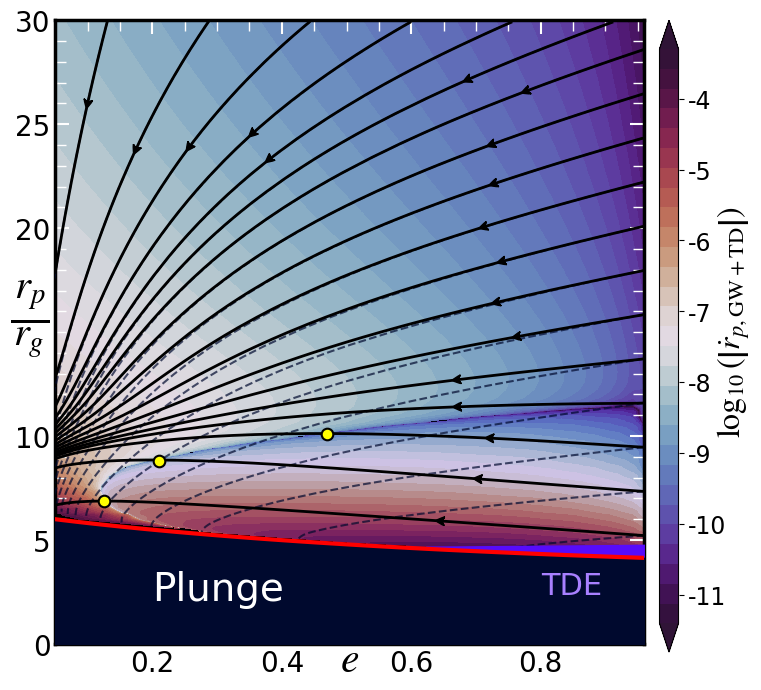

In [16]:
# ==================================================================
#  Part 3: Plotting (Exact Reproduction of the Original Figure)
# ====================================================================

plt.rcParams["mathtext.fontset"] = "stix"  # Use LaTeX-style math fonts
fig, ax1 = plt.subplots(1, 1, figsize=(7.6, 8.1))

# Black background rectangle (covers only the region where rp > 2)
rect = Rectangle((0.05, 2), 0.96 - 0.05, 30 - 2,
                 linewidth=0, edgecolor='none', facecolor="#000000", alpha=1, zorder=-1)
ax1.add_patch(rect)

# ========================
#  Colormap: Positive and negative drp/dt
# ========================
# Positive region (rp increasing) → log10(ZI_rp)
cf2 = ax1.contourf(XI, YI, np.log10(ZI_rp), 
                   levels=np.linspace(-11.4, -3.3, 30),
                   cmap='twilight_shifted', extend='both')

# drp/dt = 0 region (light blue, semi-transparent)
ax1.contourf(XI_rp_equal_1, YI_rp_equal_1, ZI_rp_equal_1,
             levels=[0, np.inf], colors=["#1400f6"], alpha=0.1)

# Negative region (rp decreasing) → log10(-ZI_rp)
cf1 = ax1.contourf(XI, YI, np.log10(-ZI_rp), 
                   levels=np.linspace(-11.8, -3.8, 50),
                   cmap='twilight_shifted', extend='both')

# ========================
#  Streamline Plotting
# ========================
# Numerically integrated streamlines (solid lines with arrows)
for line in integrated_lines:
    x, y = line['x'], line['y']
    ax1.plot(x, y, 'k-', linewidth=2, alpha=1, zorder=12)
    add_arrow_to_line(x, y, ax=ax1, position=0.3, size=15, color='k')

# GW-only streamlines (dashed lines)
for line in gw_lines:
    ax1.plot(line['x'], line['y'], color="#00092EAF", linewidth=1.5, 
             alpha=0.7, linestyle='--', zorder=5)

# ========================
#  Labels and Annotations
# ========================
ax1.text(0.2, 2.1, 'Plunge', fontsize=28, color='white', zorder=13)
ax1.text(0.8, 2.4, 'TDE', fontsize=22, color="#A880FF", zorder=15)

# TDE region fill (purple)
ax1.fill_between(e_table, rp_rt_line + 0.2, 0, color="#570BFB", alpha=1, zorder=10)

# Unstable orbit boundary (red curve + dark blue fill)
rp_curve = rp_plunge_limit_line + 0.1 + (1 - e_orbit_plunge_limit_line_table)**2 * 0.1
ax1.plot(e_orbit_plunge_limit_line_table, rp_curve, color='red', linewidth=3, zorder=13)
ax1.fill_between(e_orbit_plunge_limit_line_table, rp_curve, 0, color="#00092EFE", alpha=1, zorder=10)

# Annotated points (yellow with black edges)
ax1.scatter(e_points, rp_points, color='yellow', s=70, 
            edgecolors='black', linewidth=1.5, zorder=20)

# Axis labels (rendered with LaTeX)
ax1.text(-0.02, 15, r'$\frac{\,r_{{p} }}{r_{\mathrm{}g }} $', fontsize=42, color='black')
ax1.text(0.49, -1.3, r'$e$', fontsize=30, color='black')
ax1.text(1.07, 10.5, r'$\log_{10}  \left (  \left |  \dot{r}_{p,\mathrm{GW+TD}}    \right |   \right ) $',
         fontsize=23, color='black', rotation=90, zorder=2)

# ========================
#  Axes and Styling
# ========================
ax1.set_xlim(0.05, 0.96)
ax1.set_ylim(0, 30)

ax1.minorticks_on()
ax1.tick_params(axis='both', which='major', width=1.5, length=10, labelsize=20, direction='in', zorder=32)
ax1.tick_params(axis='both', which='minor', width=1.0, length=8, direction='in', zorder=32)
ax1.tick_params(left=True, bottom=True, right=True, top=True, which='both', color='#FFFFFF', zorder=32)

# Force x-axis tick marks to white (both top and bottom)
for ticks in [ax1.xaxis.get_major_ticks(), ax1.xaxis.get_minor_ticks()]:
    for tick in ticks:
        tick.tick1line.set_color('#FFFFFF')  # bottom ticks
        tick.tick2line.set_color('#FFFFFF')  # top ticks

# Bold black plot borders
for spine in ax1.spines.values():
    spine.set_linewidth(2.5)
    spine.set_color("#000000")

# Remove y=15 tick label to avoid overlap with text annotations
yticks = [y for y in ax1.get_yticks() if abs(y - 15) > 0.5]
ax1.set_yticks(yticks)

# ========================
#  Colorbar
# ========================
cbar_ticks = np.arange(-11, -3.1, 1)
cbar_ax = fig.add_axes([0.92, 0.1, 0.025, 0.78])  # [left, bottom, width, height]
cbar = fig.colorbar(cf2, cax=cbar_ax)
cbar.set_ticks(cbar_ticks)
cbar.set_ticklabels([int(x) for x in cbar_ticks])
cbar.ax.tick_params(labelsize=17, direction='out')

plt.show()